In [1]:
# ===========================
# 1. Import thư viện
# ===========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
import joblib, os, json

pd.set_option("display.max_columns", None)

In [2]:
# ===========================
# 2. Đọc dữ liệu
# ===========================
df = pd.read_csv("data/diabetes_binary_health_indicators_BRFSS2015.csv")

print("Kích thước dataset:", df.shape)
display(df.head())

print("Phân bố nhãn Diabetes_binary:")
print(df["Diabetes_binary"].value_counts(normalize=True))

Kích thước dataset: (253680, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Phân bố nhãn Diabetes_binary:
Diabetes_binary
0.0    0.860667
1.0    0.139333
Name: proportion, dtype: float64


In [3]:
# ===========================
# 3. Chia dữ liệu (70/15/15)
# ===========================
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"].astype(int)

# Tách train (70%) và temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Tách temp thành val (15%) và test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Tỷ lệ bệnh trong train: {y_train.mean():.3f}")

Train: (177576, 21), Val: (38052, 21), Test: (38052, 21)
Tỷ lệ bệnh trong train: 0.139


In [19]:
# ===========================
# 4. Pipeline XGBoost (với chuẩn hóa + SMOTE)
# ===========================
from sklearn.ensemble import RandomForestClassifier

pipeline = ImbPipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=42, sampling_strategy=0.5)),
        (
            "model",
            XGBClassifier(
                n_estimators=400,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                tree_method="hist",
                objective="binary:logistic",
                eval_metric="error",
                scale_pos_weight=1,
                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]
)

In [26]:
pipeline.fit(X_train, y_train)

,steps,"[('scaler', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,sampling_strategy,0.5
,random_state,42
,k_neighbors,5
,objective,'binary:logistic'


In [27]:
# ===========================
# 6. Chọn threshold dựa vào tập Validation
# ===========================
proba_val = pipeline.predict_proba(X_val)[:, 1]
prec, rec, thr = precision_recall_curve(y_val, proba_val)

target_recall = 0.8
idx = (np.abs(rec[:-1] - target_recall)).argmin()
best_threshold = thr[idx]

print(f"Threshold chọn: {best_threshold:.3f}")

Threshold chọn: 0.148


Classification Report:
              precision    recall  f1-score   support

           0      0.926     0.854     0.889     32750
           1      0.391     0.579     0.467      5302

    accuracy                          0.816     38052
   macro avg      0.659     0.717     0.678     38052
weighted avg      0.852     0.816     0.830     38052



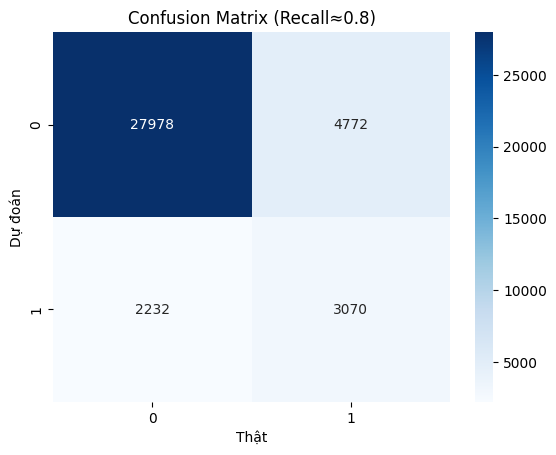

ROC-AUC: 0.829


In [ ]:
# ===========================
# 7. Đánh giá mô hình trên Test
# ===========================
proba_test = pipeline.predict_proba(X_test)[:, 1]
y_pred_custom = (proba_test >= best_threshold).astype(int)

print("Classification Report:")
print(classification_report(y_test, y_pred_custom, digits=3))

cm = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix (Recall≈{target_recall})")
plt.xlabel("Thật")
plt.ylabel("Dự đoán")
plt.show()

roc = roc_auc_score(y_test, proba_test)
print(f"ROC-AUC: {roc:.3f}")